In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================
# sqlalchemy + snowflake connector: lets Python talk to Snowflake via SQL
# pandas (pd): data manipulation library — think of it like Excel in code
# numpy (np): math library for arrays, NaN handling, log transforms
# IsolationForest: the anomaly detection model — finds "unusual" hospitals
# StandardScaler: normalizes features to mean=0, stdev=1 so no single
#                 feature dominates just because it has bigger numbers
# matplotlib (plt): charting library
# shap: explains WHY the model flagged each hospital
# =============================================================================
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import shap

In [ ]:
# =============================================================================
# SNOWFLAKE CONNECTION
# =============================================================================
# Creates a reusable connection "engine" to Snowflake.
# All pd.read_sql() calls below will use this engine to run queries.
# We only dispose() it after all queries are done (after df_2026 pull).
# =============================================================================
engine = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

In [ ]:
# =============================================================================
# 2025 DATA PULL
# =============================================================================
# Pulls one row per hospital_group × fin_market for 2025 (Jan-Dec).
# Counts distinct cases that meet each KPI condition.
#
# Filters:
#   - M&R brand, LOC-eligible (loc_flag=1)
#   - FFS population (COSMOS non-institutional + NICE FFS/Physician)
#   - IP types: Medical/Surgical/Transplant (with valid admit date) + LTAC/SNF/AIR
#   - Joined to tin_collection to get hospital_group name from TIN
#   - HAVING >= 30 cases ensures minimum volume for stable rates
#
# Does NOT include member_appeal (only available from 2026 onward).
# =============================================================================
df_2025 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202501' and '202512'
        and d.collection is not null
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

print(f"df_2025: {df_2025.shape}")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVLRbtsgFP0Viz3bYNfxHJSk8hJFi5RuWZNM7V4mDDhhweACrtu%2FH3YSqXtopT0gITjnnnPvuZPbl1oGz9xYodUUxBECAVdUM6EOU7DfLcMcBNYRxYjUik%2FBK7fgdjaxpJYNLlp3VPf8qeXWBb6Qsrj%2FmILWKKyJFRYrUnOLHcXb4m6NkwhhYi03zsuBC4VZ4bWOzjUYwq7rou4m0uYAE4QQRGPoUT3kE3gj0Xys0RjtNNXySnnxPb0jEUOU9hIe4RU2F%2BIXoc4j%2BEilPIMs%2FrrbbcLN9%2B0OBMW1u7lWtq252XLzLCjf36%2FPBqx30B4PoT%2BsI8T%2BPpLIKt1Vkpw41XXTOl8z8jdYcQalPgg%2FqdViCpqTYOzJrKtlaR5%2FPJw6mhZNneS02%2F9J7x74I9LzvUSFruWN6DQFwc9rrkmf68ralq9Un6bzTyjJQpSFcb6LM4xyPMqiPI5%2FgWDh0xSKuIF5tTz4iGpBjba6clpJofjgkpVoVBFKQponJEzLMQvLMR2FqMrSMvs8GqVJDPvMEnDeGzwYMbP%2Fm8YEvuVeFvCbz2S12Ggp6Guw1KYm7v3I4igeXgQLqwGKeU2ELBgz3FofnZS6mxtOnN9zZ1oO4Oys%2Bu%2Bmz%2F4C&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7bfiDrABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEA6ScI7z2HBhHjBCNuDLgiMAAACQwaKrZ%2FoQIiCVmR

In [ ]:
# =============================================================================
# 2025: COMPUTE RATES + EMPIRICAL BAYES SHRINKAGE + LOG-VOLUME
# =============================================================================

# --- Step 1: raw rates ---
df_2025 = df_2025.assign(
    initial_adr_rate = lambda x: x.initial_adr_cnt / x.case_count,
    persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count,
    p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
    appeal_overturn_rate = lambda x: x.appeal_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
    mcr_overturn_rate = lambda x: x.mcr_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
    md_review_rate = lambda x: x.md_reviewed_cnt / x.case_count,
)

rate_cols_25 = [
    "initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate"
]
adj_rate_cols_25 = [
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate"
]
count_cols_25 = [
    "case_count", "initial_adr_cnt", "persistent_adr_cnt",
    "p2p_ovrtn_cnt", "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt"
]
df_2025[rate_cols_25 + count_cols_25] = df_2025[rate_cols_25 + count_cols_25].replace([np.inf, -np.inf], np.nan).fillna(0)

# --- Step 2: eligibility filter ---
df_iso_25 = df_2025.query("case_count >= 30 and initial_adr_cnt >= 10").copy()

# --- Save raw rate medians BEFORE shrinkage ---
raw_medians_25 = df_iso_25[rate_cols_25].median()

# --- Step 3: Bayes shrinkage → *_adj_rate columns ---
k = 50

gr_initial_adr = df_iso_25["initial_adr_cnt"].sum() / df_iso_25["case_count"].sum()
gr_persistent = df_iso_25["persistent_adr_cnt"].sum() / df_iso_25["case_count"].sum()
gr_p2p = df_iso_25["p2p_ovrtn_cnt"].sum() / df_iso_25["initial_adr_cnt"].sum()
gr_appeal = df_iso_25["appeal_ovrtn_cnt"].sum() / df_iso_25["initial_adr_cnt"].sum()
gr_mcr = df_iso_25["mcr_ovrtn_cnt"].sum() / df_iso_25["initial_adr_cnt"].sum()
gr_md = df_iso_25["md_reviewed_cnt"].sum() / df_iso_25["case_count"].sum()

df_iso_25 = df_iso_25.assign(
    initial_adr_adj_rate = lambda x: (x.initial_adr_cnt + k * gr_initial_adr) / (x.case_count + k),
    persistent_adr_adj_rate = lambda x: (x.persistent_adr_cnt + k * gr_persistent) / (x.case_count + k),
    p2p_overturn_adj_rate = lambda x: (x.p2p_ovrtn_cnt + k * gr_p2p) / (x.initial_adr_cnt + k),
    appeal_overturn_adj_rate = lambda x: (x.appeal_ovrtn_cnt + k * gr_appeal) / (x.initial_adr_cnt + k),
    mcr_overturn_adj_rate = lambda x: (x.mcr_ovrtn_cnt + k * gr_mcr) / (x.initial_adr_cnt + k),
    md_review_adj_rate = lambda x: (x.md_reviewed_cnt + k * gr_md) / (x.case_count + k),
    log_case_count = lambda x: np.log1p(x.case_count),
    log_initial_adr_cnt = lambda x: np.log1p(x.initial_adr_cnt),
)

# --- The feature list that goes into IF (uses adj rates) ---
iso_kpi_25 = [
    "log_case_count", "log_initial_adr_cnt",
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate"
]
df_iso_25[iso_kpi_25] = df_iso_25[iso_kpi_25].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"2025 IF-ready: {df_iso_25.shape[0]} hospitals, {len(iso_kpi_25)} features")

2025 IF-ready: 1226 hospitals, 8 features


In [ ]:
# =============================================================================
# 2025: ISOLATION FOREST
# =============================================================================
#
# StandardScaler: normalizes each feature to mean=0, stdev=1.
#   Without this, a feature like log_case_count (range 3-9) would be dwarfed by
#   a feature like initial_adr_rate (range 0.01-0.50) in terms of variance.
#   Scaling ensures IF treats all features equally.
#
# IsolationForest:
#   - Builds 300 random decision trees (n_estimators=300)
#   - Each tree randomly picks a feature and a split point, trying to isolate
#     each hospital into its own leaf as fast as possible
#   - Anomalies are points that get isolated QUICKLY (short path = few splits)
#     because their feature values are far from the crowd
#   - contamination=0.05: tells the model "expect ~5% of hospitals to be anomalous"
#   - random_state=42: makes results reproducible (same answer every run)
#
# decision_function(X): returns the anomaly score
#   - Negative = anomalous (short average path length)
#   - Positive = normal (long average path length)
#   - More negative = more anomalous
#
# predict(X): returns 1 (normal) or -1 (anomaly)
#   - We convert to True/False with == -1
#
# anomaly_rank: rank 1 = most anomalous, rank N = least anomalous
# =============================================================================

# Scale the features
scaler_25 = StandardScaler()
X_25 = scaler_25.fit_transform(df_iso_25[iso_kpi_25])

# Train the Isolation Forest
iso_model_25 = IsolationForest(contamination = 0.05, n_estimators = 300, random_state = 42)
iso_model_25.fit(X_25)

# Score every hospital
df_iso_25 = df_iso_25.assign(
    anomaly_score = iso_model_25.decision_function(X_25),  # continuous score
    anomaly_flag = iso_model_25.predict(X_25) == -1,       # True if anomalous
)
# Rank: 1 = most anomalous (lowest score)
df_iso_25["anomaly_rank"] = df_iso_25["anomaly_score"].rank(method = "dense", ascending = True).astype(int)

print(f"2025 Flagged: {df_iso_25['anomaly_flag'].sum()} / {df_iso_25.shape[0]} hospitals")

2025 Flagged: 62 / 1226 hospitals


In [ ]:
# =============================================================================
# 2025: SHAP EXPLAINER
# =============================================================================
#
# TreeExplainer: analyzes the IF model's internal tree structure to compute
#   how much each feature contributed to each hospital's anomaly score.
#
# explainer.expected_value = E[f(x)]:
#   The average path length across all hospitals. This is the "baseline" —
#   what the model predicts for a completely average hospital.
#
# shap_values = explainer.shap_values(X_25):
#   Returns a matrix of shape (n_hospitals × n_features).
#   Each cell = "how much did this feature push THIS hospital's path length
#   away from the baseline?"
#   - Negative SHAP value = pushed toward SHORTER path = more anomalous
#   - Positive SHAP value = pushed toward LONGER path = more normal
#
# Key property: base_value + sum(shap_values[i]) = f(x_i) for hospital i
#   (the SHAP values perfectly decompose the model's output)
# =============================================================================
explainer_25 = shap.TreeExplainer(iso_model_25)
shap_values_25 = explainer_25.shap_values(X_25)

print(f"2025 SHAP values shape: {shap_values_25.shape}")

2025 SHAP values shape: (1226, 8)


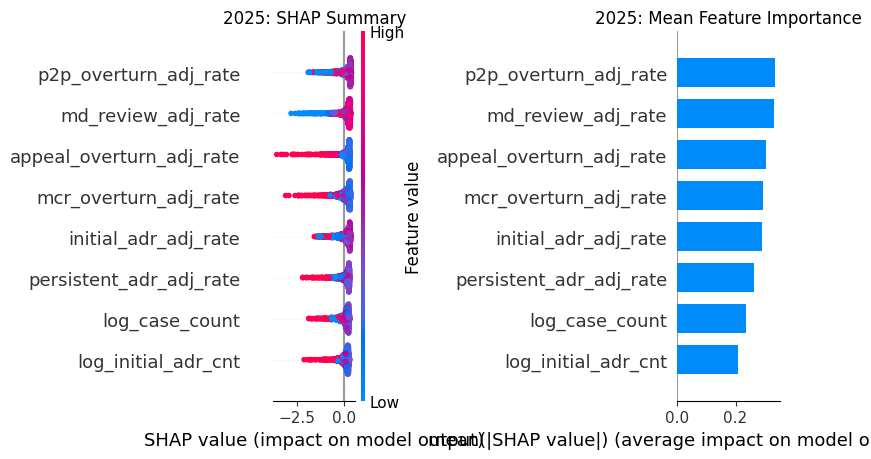

In [ ]:
# =============================================================================
# 2025: SHAP PLOTS
# =============================================================================
#
# LEFT (Beeswarm/Summary): Each dot = one hospital. Shows ALL hospitals.
#   - X-axis = SHAP value (how much this feature pushed the score)
#   - Y-axis = features ranked by importance
#   - Color = actual feature value (red=high, blue=low)
#   - Interpretation: if red dots cluster left → high values of that feature
#     push hospitals toward anomaly
#
# RIGHT (Bar): Mean |SHAP value| per feature across ALL hospitals.
#   - Taller bar = the IF model relies on this feature more heavily
#     when deciding who's normal vs anomalous
#   - This is GLOBAL model behavior, not specific to any one hospital
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize = (16, 5))

plt.sca(axes[0])
shap.summary_plot(shap_values_25, X_25, feature_names = iso_kpi_25, show = False)
axes[0].set_title("2025: SHAP Summary")

plt.sca(axes[1])
shap.summary_plot(shap_values_25, X_25, feature_names = iso_kpi_25, plot_type = "bar", show = False)
axes[1].set_title("2025: Mean Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 2025: SHAP FLAGGED HOSPITAL DRIVERS
# =============================================================================
#
# For each FLAGGED hospital only, we look at its SHAP values and find:
#   - shap_driver: which feature had the MOST NEGATIVE shap value
#     (= biggest push toward anomaly). This is the "top reason" it was flagged.
#   - shap_driver_value: the actual SHAP contribution (e.g., -2.31 means
#     this feature shortened the path length by 2.31 units)
#   - driver_actual_value: the hospital's actual rate/count for that feature
#     (e.g., if driver is p2p_overturn_rate, this shows the actual 0.42 rate)
#
# idxmin(axis=1): for each row, find the column name with the smallest value
#   → gives us the feature name with most negative SHAP contribution
# =============================================================================
flagged_idx_25 = df_iso_25[df_iso_25["anomaly_flag"]].index
flagged_pos_25 = [df_iso_25.index.get_loc(idx) for idx in flagged_idx_25]

# Build a DataFrame of SHAP values for flagged hospitals only
shap_flagged_25 = pd.DataFrame(
    shap_values_25[flagged_pos_25],
    columns = iso_kpi_25,
    index = flagged_idx_25
)
shap_flagged_25["hospital_group"] = df_iso_25.loc[flagged_idx_25, "hospital_group"].values
shap_flagged_25["fin_market"] = df_iso_25.loc[flagged_idx_25, "fin_market"].values
shap_flagged_25["anomaly_rank"] = df_iso_25.loc[flagged_idx_25, "anomaly_rank"].values

# Find the feature with the most negative SHAP value (biggest push toward anomaly)
shap_flagged_25["shap_driver"] = shap_flagged_25[iso_kpi_25].idxmin(axis = 1)
shap_flagged_25["shap_driver_value"] = shap_flagged_25[iso_kpi_25].min(axis = 1)

# Look up the hospital's actual value for that driver feature
shap_flagged_25["driver_actual_value"] = shap_flagged_25.apply(
    lambda r: df_iso_25.loc[r.name, r["shap_driver"]], axis = 1
)

print(f"2025 Flagged: {len(shap_flagged_25)} hospitals")
shap_flagged_25[["hospital_group", "fin_market", "anomaly_rank", "shap_driver", "shap_driver_value", "driver_actual_value"]].sort_values("anomaly_rank")

2025 Flagged: 62 hospitals


,hospital_group,fin_market,anomaly_rank,shap_driver,shap_driver_value,driver_actual_value
908,OKLAHOMA SPINE HOSPITAL,OK,1,appeal_overturn_adj_rate,-3.173782,0.106275
778,Ascension MI,MI,2,md_review_adj_rate,-1.776888,0.135100
641,Froedtert,WI,3,mcr_overturn_adj_rate,-2.604722,0.153582
134,MAYO CLINIC,MN,4,md_review_adj_rate,-2.160589,0.074177
250,ADVOCATE HEALTH & HOSPITALS IL,IL,5,md_review_adj_rate,-2.379988,0.027064
...,...,...,...,...,...,...
920,CULLMAN REGIONAL MEDICAL CTR,AL,58,persistent_adr_adj_rate,-1.688850,0.315331
405,Kaleida,NY,59,md_review_adj_rate,-1.707308,0.261230
1142,RCHP - FLORENCE,AL,60,mcr_overturn_adj_rate,-1.984351,0.099237
366,HCA INC,TX,61,log_initial_adr_cnt,-1.961501,8.732627



OKLAHOMA SPINE HOSPITAL | Rank #1 (2025)


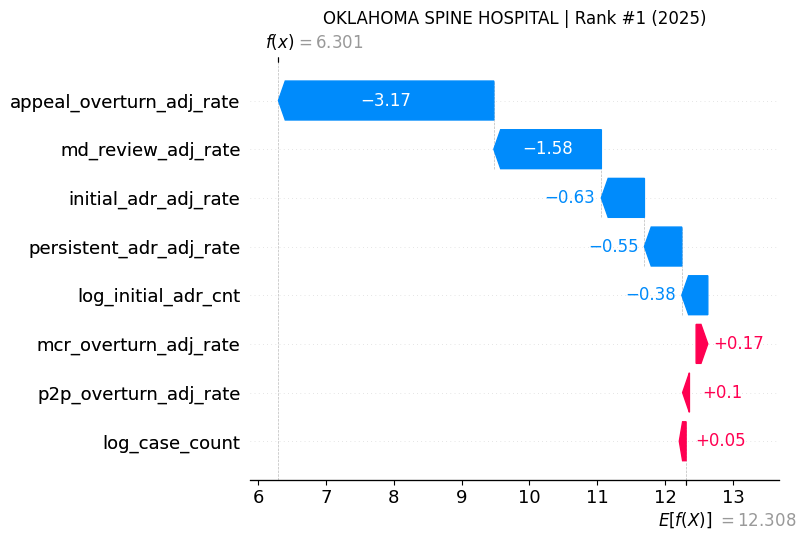


Ascension MI | Rank #2 (2025)


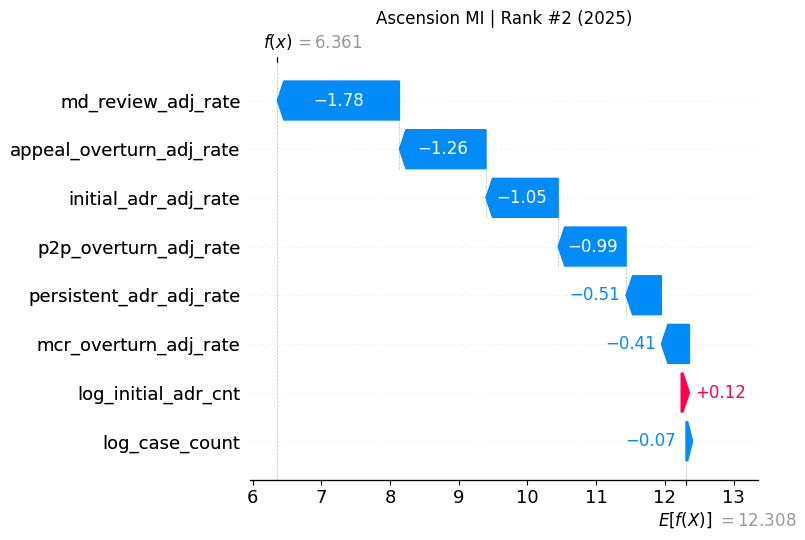


Froedtert | Rank #3 (2025)


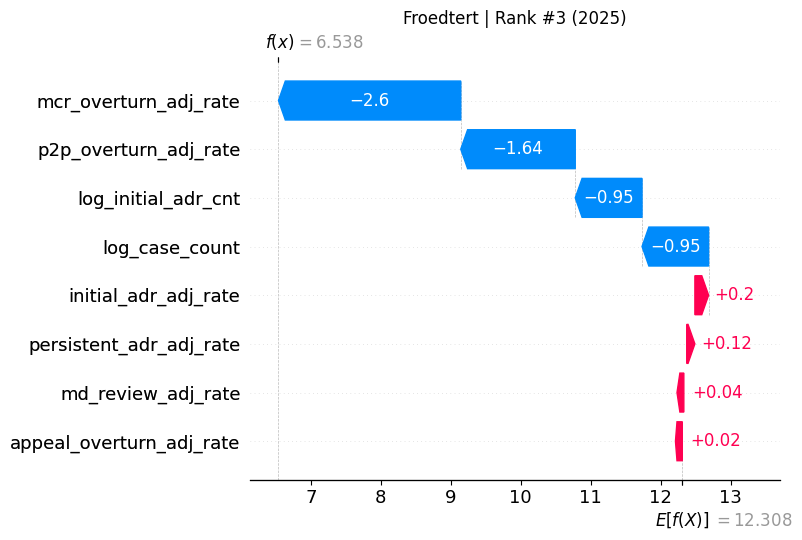


MAYO CLINIC | Rank #4 (2025)


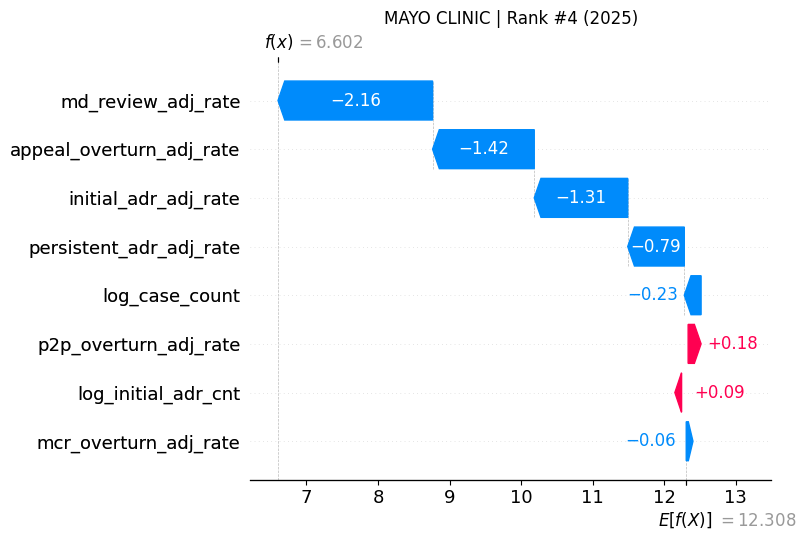


ADVOCATE HEALTH & HOSPITALS IL | Rank #5 (2025)


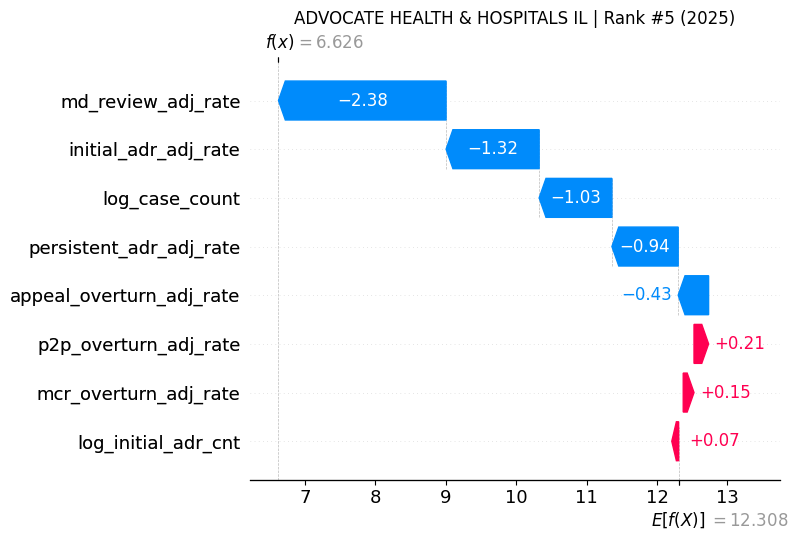

In [ ]:
# =============================================================================
# 2025: SHAP WATERFALL — TOP 5 MOST ANOMALOUS
# =============================================================================
#
# For each of the 5 most anomalous hospitals, shows a waterfall chart:
#   - Starts at E[f(x)] (base value = average path length for a typical hospital)
#   - Each bar = one feature's SHAP contribution
#   - Blue bars push LEFT (shorter path → more anomalous)
#   - Red bars push RIGHT (longer path → more normal)
#   - Ends at f(x) = this hospital's actual path length
#
# If f(x) << E[f(x)], the hospital was isolated very quickly → very anomalous.
#
# Note: SHAP works on path length (higher = more normal), while anomaly_score
# from decision_function is the opposite (lower = more anomalous). The waterfall
# uses the raw path length scale.
# =============================================================================

# Get the 5 hospitals with the lowest anomaly scores (most anomalous)
top5_idx_25 = (
    df_iso_25[df_iso_25["anomaly_flag"] & df_iso_25["hospital_group"].notna()]
    .nsmallest(5, "anomaly_score")
    .index
)

# base_val = E[f(x)] = expected path length for an average hospital
base_val_25 = float(explainer_25.expected_value) if np.ndim(explainer_25.expected_value) == 0 else float(explainer_25.expected_value[0])

for idx in top5_idx_25:
    pos = df_iso_25.index.get_loc(idx)
    hospital_name = df_iso_25.loc[idx, "hospital_group"]
    rank = int(df_iso_25.loc[idx, "anomaly_rank"])

    print(f"\n{'='*60}")
    print(f"{hospital_name} | Rank #{rank} (2025)")
    print(f"{'='*60}")

    # Create a SHAP Explanation object for this single hospital
    explanation = shap.Explanation(
        values = shap_values_25[pos],      # this hospital's SHAP values
        base_values = base_val_25,          # E[f(x)]
        feature_names = iso_kpi_25
    )
    shap.waterfall_plot(explanation, show = False)
    plt.title(f"{hospital_name[:35]} | Rank #{rank} (2025)")
    plt.tight_layout()
    plt.show()

In [ ]:
# =============================================================================
# 2025: OUTPUT ASSEMBLY
# =============================================================================

adj_to_raw_25 = dict(zip(adj_rate_cols_25, rate_cols_25))

df_iso_25["driver"] = shap_flagged_25["shap_driver"].reindex(df_iso_25.index).fillna("")

df_iso_25["direction"] = np.where(
    df_iso_25["anomaly_flag"],
    df_iso_25.apply(lambda r: "high" if r["driver"] and df_iso_25.loc[r.name, r["driver"]] > df_iso_25[r["driver"]].median() else "low", axis=1),
    ""
)
df_iso_25["reason"] = np.where(df_iso_25["anomaly_flag"], df_iso_25["driver"] + " (" + df_iso_25["direction"] + ")", "")

adj_medians_25 = df_iso_25[iso_kpi_25].median()
raw_med_case = df_iso_25["case_count"].median()
raw_med_adr = df_iso_25["initial_adr_cnt"].median()

df_iso_25["driver_value"] = np.nan
df_iso_25["driver_adj_median"] = np.nan
df_iso_25["driver_raw_median"] = np.nan
df_iso_25["driver_dev"] = np.nan

mask = df_iso_25["anomaly_flag"] & (df_iso_25["driver"] == "log_case_count")
df_iso_25.loc[mask, "driver_value"] = df_iso_25.loc[mask, "case_count"]
df_iso_25.loc[mask, "driver_adj_median"] = raw_med_case
df_iso_25.loc[mask, "driver_raw_median"] = raw_med_case
df_iso_25.loc[mask, "driver_dev"] = (df_iso_25.loc[mask, "case_count"] - raw_med_case) / raw_med_case

mask = df_iso_25["anomaly_flag"] & (df_iso_25["driver"] == "log_initial_adr_cnt")
df_iso_25.loc[mask, "driver_value"] = df_iso_25.loc[mask, "initial_adr_cnt"]
df_iso_25.loc[mask, "driver_adj_median"] = raw_med_adr
df_iso_25.loc[mask, "driver_raw_median"] = raw_med_adr
df_iso_25.loc[mask, "driver_dev"] = (df_iso_25.loc[mask, "initial_adr_cnt"] - raw_med_adr) / raw_med_adr

for ac in adj_rate_cols_25:
    mask = df_iso_25["anomaly_flag"] & (df_iso_25["driver"] == ac)
    if mask.any():
        df_iso_25.loc[mask, "driver_value"] = df_iso_25.loc[mask, ac]
        df_iso_25.loc[mask, "driver_adj_median"] = adj_medians_25[ac]
        df_iso_25.loc[mask, "driver_raw_median"] = raw_medians_25[adj_to_raw_25[ac]]
        df_iso_25.loc[mask, "driver_dev"] = (df_iso_25.loc[mask, ac] - adj_medians_25[ac]) / adj_medians_25[ac]

output_cols_25 = [
    "hospital_group", "fin_market",
    *count_cols_25, *rate_cols_25, *iso_kpi_25,
    "anomaly_score", "anomaly_rank", "anomaly_flag",
    "driver", "direction", "reason",
    "driver_value", "driver_adj_median", "driver_raw_median", "driver_dev"
]
df_iso_output_25 = df_iso_25[output_cols_25].sort_values("anomaly_score").reset_index(drop = True)
df_iso_output_25["year"] = "2025"

print(f"2025 output: {df_iso_output_25.shape[0]} rows | Flagged: {df_iso_output_25['anomaly_flag'].sum()}")
df_iso_output_25[df_iso_output_25["anomaly_flag"]]

2025 output: 1226 rows | Flagged: 62


,hospital_group,fin_market,case_count,initial_adr_cnt,persistent_adr_cnt,p2p_ovrtn_cnt,appeal_ovrtn_cnt,mcr_ovrtn_cnt,md_reviewed_cnt,initial_adr_rate,...,anomaly_rank,anomaly_flag,driver,direction,reason,driver_value,driver_adj_median,driver_raw_median,driver_dev,year
0,OKLAHOMA SPINE HOSPITAL,OK,138,10,2,0,6,0,8,0.072464,...,1,True,appeal_overturn_adj_rate,high,appeal_overturn_adj_rate (high),0.106275,0.005619,0.000000,17.911856,2025
1,Ascension MI,MI,1330,93,65,0,4,6,154,0.069925,...,2,True,md_review_adj_rate,low,md_review_adj_rate (low),0.135100,0.691930,0.702137,-0.804749,2025
2,Froedtert,WI,8223,2264,1054,0,6,354,5091,0.275325,...,3,True,mcr_overturn_adj_rate,high,mcr_overturn_adj_rate (high),0.153582,0.022535,0.018070,5.815413,2025
3,MAYO CLINIC,MN,1695,57,22,23,3,0,97,0.033628,...,4,True,md_review_adj_rate,low,md_review_adj_rate (low),0.074177,0.691930,0.702137,-0.892798,2025
4,ADVOCATE HEALTH & HOSPITALS IL,IL,7393,78,42,27,2,1,169,0.010551,...,5,True,md_review_adj_rate,low,md_review_adj_rate (low),0.027064,0.691930,0.702137,-0.960886,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,CULLMAN REGIONAL MEDICAL CTR,AL,1008,465,326,129,0,4,855,0.461310,...,58,True,persistent_adr_adj_rate,high,persistent_adr_adj_rate (high),0.315331,0.150714,0.150063,1.092242,2025
58,Kaleida,NY,924,88,32,52,1,3,222,0.095238,...,59,True,md_review_adj_rate,low,md_review_adj_rate (low),0.261230,0.691930,0.702137,-0.622462,2025
59,RCHP - FLORENCE,AL,1002,357,206,24,4,39,668,0.356287,...,60,True,mcr_overturn_adj_rate,high,mcr_overturn_adj_rate (high),0.099237,0.022535,0.018070,3.403756,2025
60,HCA INC,TX,19135,6201,3011,2736,74,240,13110,0.324066,...,61,True,log_initial_adr_cnt,high,log_initial_adr_cnt (high),6201.000000,65.000000,65.000000,94.400000,2025


In [ ]:
# =============================================================================
# 2026 DATA PULL
# =============================================================================
# Same structure as 2025 but:
#   - Filters to hce_admit_month >= '202601' (2026 onward)
#   - HAVING >= 10 initial ADRs (lower threshold because fewer months of data)
#   - Includes member_appeal_cnt and member_appeal_ovtn_cnt (new KPI for 2026)
# =============================================================================
df_2026 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt
        , count(distinct case when a.member_appeal_ovtn_ind = 1 then a.case_id end) as member_appeal_ovtn_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month >= '202601'
        and d.collection is not null
    group by 1,2
    having count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) >= 10
""", engine)

engine.dispose()  # Done with both pulls — close the connection
print(f"df_2026: {df_2026.shape}")

df_2026: (938, 11)


In [ ]:
# =============================================================================
# 2026: COMPUTE RATES + BAYES SHRINKAGE + LOG-VOLUME
# =============================================================================

df_2026 = df_2026.assign(
    initial_adr_rate = lambda x: x.initial_adr_cnt / x.case_count,
    persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count,
    p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
    appeal_overturn_rate = lambda x: x.appeal_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
    mcr_overturn_rate = lambda x: x.mcr_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
    md_review_rate = lambda x: x.md_reviewed_cnt / x.case_count,
    member_appeal_rate = lambda x: x.member_appeal_cnt / x.initial_adr_cnt.replace(0, np.nan),
)

rate_cols_26 = [
    "initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
    "member_appeal_rate"
]
adj_rate_cols_26 = [
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
    "member_appeal_adj_rate"
]
count_cols_26 = [
    "case_count", "initial_adr_cnt", "persistent_adr_cnt",
    "p2p_ovrtn_cnt", "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt",
    "member_appeal_cnt", "member_appeal_ovtn_cnt"
]
df_2026[rate_cols_26 + count_cols_26] = df_2026[rate_cols_26 + count_cols_26].replace([np.inf, -np.inf], np.nan).fillna(0)

df_iso_26 = df_2026.query("case_count >= 30 and initial_adr_cnt >= 10").copy()

# --- Save raw rate medians BEFORE shrinkage ---
raw_medians_26 = df_iso_26[rate_cols_26].median()

k = 50
gr_initial_adr = df_iso_26["initial_adr_cnt"].sum() / df_iso_26["case_count"].sum()
gr_persistent = df_iso_26["persistent_adr_cnt"].sum() / df_iso_26["case_count"].sum()
gr_p2p = df_iso_26["p2p_ovrtn_cnt"].sum() / df_iso_26["initial_adr_cnt"].sum()
gr_appeal = df_iso_26["appeal_ovrtn_cnt"].sum() / df_iso_26["initial_adr_cnt"].sum()
gr_mcr = df_iso_26["mcr_ovrtn_cnt"].sum() / df_iso_26["initial_adr_cnt"].sum()
gr_md = df_iso_26["md_reviewed_cnt"].sum() / df_iso_26["case_count"].sum()
gr_member_appeal = df_iso_26["member_appeal_cnt"].sum() / df_iso_26["initial_adr_cnt"].sum()

df_iso_26 = df_iso_26.assign(
    initial_adr_adj_rate = lambda x: (x.initial_adr_cnt + k * gr_initial_adr) / (x.case_count + k),
    persistent_adr_adj_rate = lambda x: (x.persistent_adr_cnt + k * gr_persistent) / (x.case_count + k),
    p2p_overturn_adj_rate = lambda x: (x.p2p_ovrtn_cnt + k * gr_p2p) / (x.initial_adr_cnt + k),
    appeal_overturn_adj_rate = lambda x: (x.appeal_ovrtn_cnt + k * gr_appeal) / (x.initial_adr_cnt + k),
    mcr_overturn_adj_rate = lambda x: (x.mcr_ovrtn_cnt + k * gr_mcr) / (x.initial_adr_cnt + k),
    md_review_adj_rate = lambda x: (x.md_reviewed_cnt + k * gr_md) / (x.case_count + k),
    member_appeal_adj_rate = lambda x: (x.member_appeal_cnt + k * gr_member_appeal) / (x.initial_adr_cnt + k),
    log_case_count = lambda x: np.log1p(x.case_count),
    log_initial_adr_cnt = lambda x: np.log1p(x.initial_adr_cnt),
)

# --- The feature list that goes into IF (uses adj rates) ---
iso_kpi_26 = [
    "log_case_count", "log_initial_adr_cnt",
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
    "member_appeal_adj_rate"
]
df_iso_26[iso_kpi_26] = df_iso_26[iso_kpi_26].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"2026 IF-ready: {df_iso_26.shape[0]} hospitals, {len(iso_kpi_26)} features")

2026 IF-ready: 885 hospitals, 9 features


In [ ]:
# =============================================================================
# 2026: ISOLATION FOREST (same approach as 2025)
# =============================================================================
scaler_26 = StandardScaler()
X_26 = scaler_26.fit_transform(df_iso_26[iso_kpi_26])

iso_model_26 = IsolationForest(contamination = 0.05, n_estimators = 300, random_state = 42)
iso_model_26.fit(X_26)

df_iso_26 = df_iso_26.assign(
    anomaly_score = iso_model_26.decision_function(X_26),
    anomaly_flag = iso_model_26.predict(X_26) == -1,
)
df_iso_26["anomaly_rank"] = df_iso_26["anomaly_score"].rank(method = "dense", ascending = True).astype(int)

print(f"2026 Flagged: {df_iso_26['anomaly_flag'].sum()} / {df_iso_26.shape[0]} hospitals")

2026 Flagged: 45 / 885 hospitals


In [ ]:
# =============================================================================
# 2026: SHAP EXPLAINER (same approach as 2025)
# =============================================================================
explainer_26 = shap.TreeExplainer(iso_model_26)
shap_values_26 = explainer_26.shap_values(X_26)

print(f"2026 SHAP values shape: {shap_values_26.shape}")

2026 SHAP values shape: (885, 9)


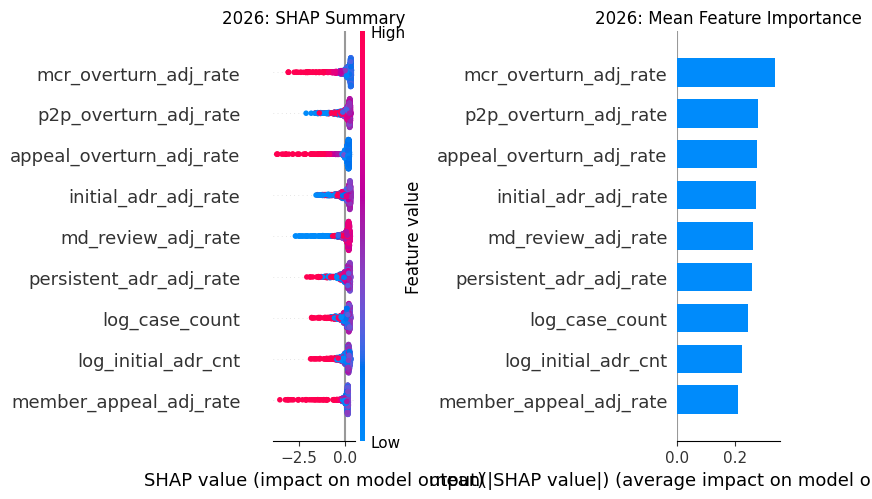

In [ ]:
# =============================================================================
# 2026: SHAP PLOTS (same approach as 2025)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize = (16, 5))

plt.sca(axes[0])
shap.summary_plot(shap_values_26, X_26, feature_names = iso_kpi_26, show = False)
axes[0].set_title("2026: SHAP Summary")

plt.sca(axes[1])
shap.summary_plot(shap_values_26, X_26, feature_names = iso_kpi_26, plot_type = "bar", show = False)
axes[1].set_title("2026: Mean Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 2026: SHAP FLAGGED HOSPITAL DRIVERS (same approach as 2025)
# =============================================================================
flagged_idx_26 = df_iso_26[df_iso_26["anomaly_flag"]].index
flagged_pos_26 = [df_iso_26.index.get_loc(idx) for idx in flagged_idx_26]

shap_flagged_26 = pd.DataFrame(
    shap_values_26[flagged_pos_26],
    columns = iso_kpi_26,
    index = flagged_idx_26
)
shap_flagged_26["hospital_group"] = df_iso_26.loc[flagged_idx_26, "hospital_group"].values
shap_flagged_26["fin_market"] = df_iso_26.loc[flagged_idx_26, "fin_market"].values
shap_flagged_26["anomaly_rank"] = df_iso_26.loc[flagged_idx_26, "anomaly_rank"].values
shap_flagged_26["shap_driver"] = shap_flagged_26[iso_kpi_26].idxmin(axis = 1)
shap_flagged_26["shap_driver_value"] = shap_flagged_26[iso_kpi_26].min(axis = 1)
shap_flagged_26["driver_actual_value"] = shap_flagged_26.apply(
    lambda r: df_iso_26.loc[r.name, r["shap_driver"]], axis = 1
)

print(f"2026 Flagged: {len(shap_flagged_26)} hospitals")
shap_flagged_26[["hospital_group", "fin_market", "anomaly_rank", "shap_driver", "shap_driver_value", "driver_actual_value"]].sort_values("anomaly_rank")

2026 Flagged: 45 hospitals


,hospital_group,fin_market,anomaly_rank,shap_driver,shap_driver_value,driver_actual_value
522,Atrium Health System,NC,1,member_appeal_adj_rate,-2.816932,0.667924
703,ADVOCATE HEALTH & HOSPITALS IL,IL,2,appeal_overturn_adj_rate,-2.549550,0.036114
465,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,3,member_appeal_adj_rate,-3.001397,0.629006
114,FLOYD HEALTHCARE MANAGEMENT,GA,4,member_appeal_adj_rate,-3.087487,0.461337
551,HEALTH SERVICES OF CENTRAL GA,GA,5,member_appeal_adj_rate,-3.263871,0.574219
62,HUGH CHATHAM MEMORIAL HOSPITAL,NC,6,member_appeal_adj_rate,-3.193736,0.414783
459,Stanford Health Hospital,CA-N,7,appeal_overturn_adj_rate,-3.673540,0.058687
854,Englewood Hospital,NJ,8,persistent_adr_adj_rate,-1.876757,0.431489
36,Hoag Memorial Hospital,CA-S,9,mcr_overturn_adj_rate,-2.659578,0.063680
363,CATHOLIC HEALTHCARE WEST,CA-N,10,md_review_adj_rate,-2.048581,0.227228



Atrium Health System | Rank #1 (2026)


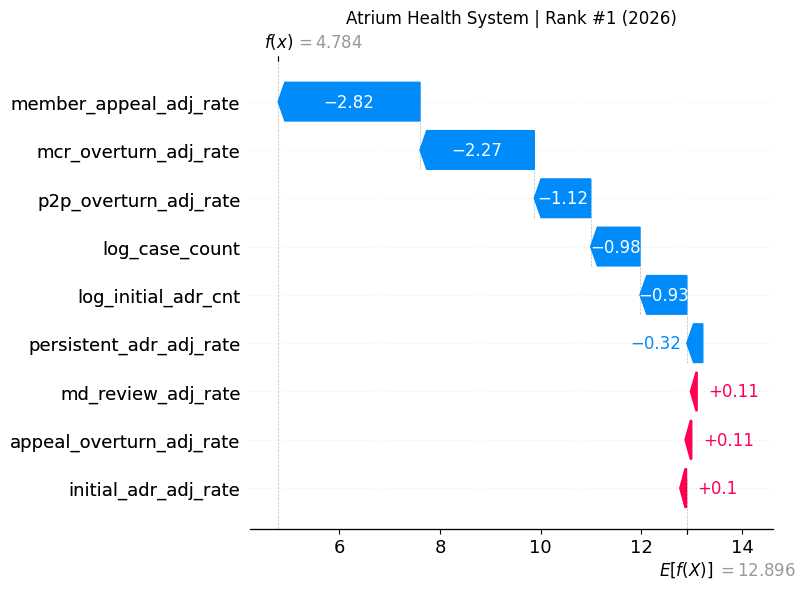


ADVOCATE HEALTH & HOSPITALS IL | Rank #2 (2026)


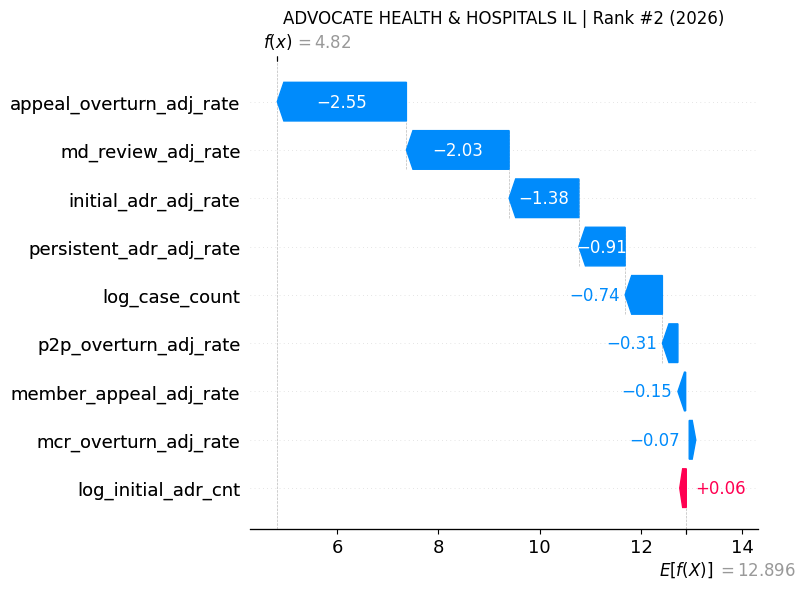


NORTH CAROLINA BAPTIST HOSPITAL SYSTEM | Rank #3 (2026)


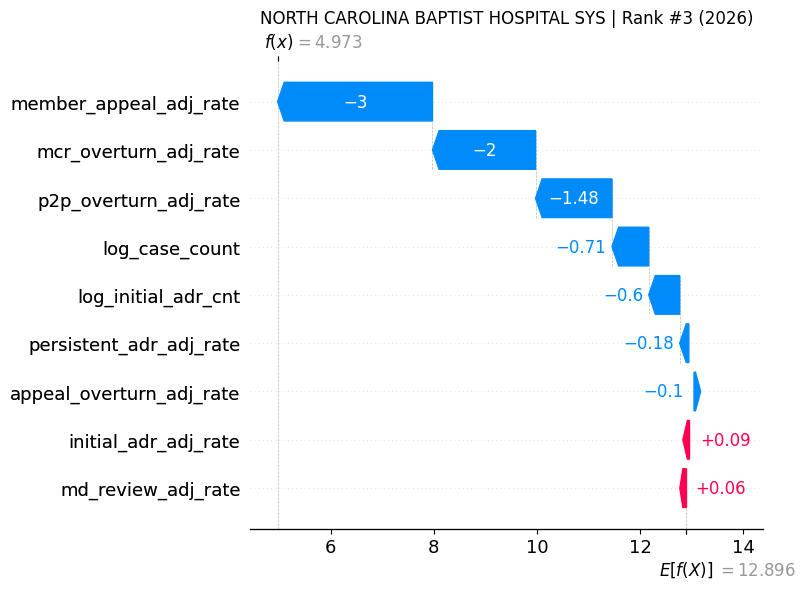


FLOYD HEALTHCARE MANAGEMENT | Rank #4 (2026)


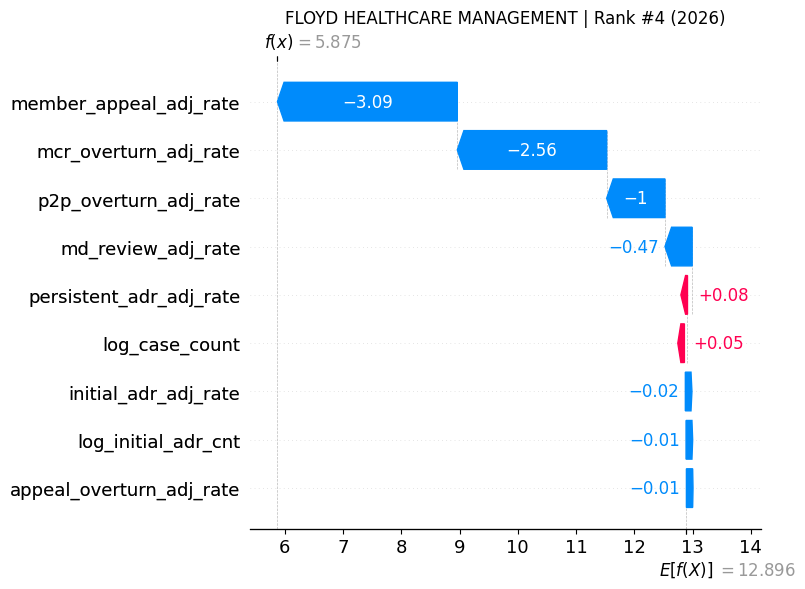


HEALTH SERVICES OF CENTRAL GA | Rank #5 (2026)


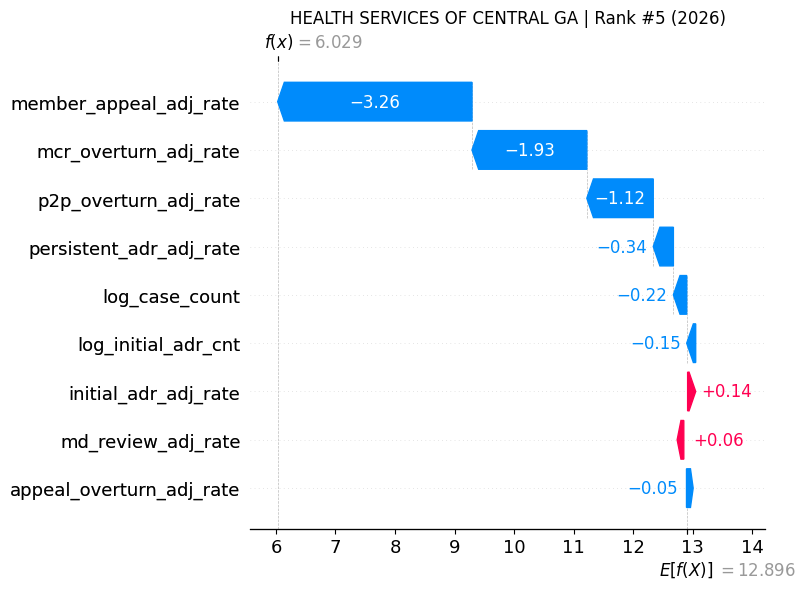

In [ ]:
# =============================================================================
# 2026: SHAP WATERFALL — TOP 5 (same approach as 2025)
# =============================================================================
top5_idx_26 = (
    df_iso_26[df_iso_26["anomaly_flag"] & df_iso_26["hospital_group"].notna()]
    .nsmallest(5, "anomaly_score")
    .index
)

base_val_26 = float(explainer_26.expected_value) if np.ndim(explainer_26.expected_value) == 0 else float(explainer_26.expected_value[0])

for idx in top5_idx_26:
    pos = df_iso_26.index.get_loc(idx)
    hospital_name = df_iso_26.loc[idx, "hospital_group"]
    rank = int(df_iso_26.loc[idx, "anomaly_rank"])

    print(f"\n{'='*60}")
    print(f"{hospital_name} | Rank #{rank} (2026)")
    print(f"{'='*60}")

    explanation = shap.Explanation(
        values = shap_values_26[pos],
        base_values = base_val_26,
        feature_names = iso_kpi_26
    )
    shap.waterfall_plot(explanation, show = False)
    plt.title(f"{hospital_name[:35]} | Rank #{rank} (2026)")
    plt.tight_layout()
    plt.show()

In [ ]:
# =============================================================================
# 2026: OUTPUT ASSEMBLY
# =============================================================================

adj_to_raw_26 = dict(zip(adj_rate_cols_26, rate_cols_26))

df_iso_26["driver"] = shap_flagged_26["shap_driver"].reindex(df_iso_26.index).fillna("")

df_iso_26["direction"] = np.where(
    df_iso_26["anomaly_flag"],
    df_iso_26.apply(lambda r: "high" if r["driver"] and df_iso_26.loc[r.name, r["driver"]] > df_iso_26[r["driver"]].median() else "low", axis=1),
    ""
)
df_iso_26["reason"] = np.where(df_iso_26["anomaly_flag"], df_iso_26["driver"] + " (" + df_iso_26["direction"] + ")", "")

adj_medians_26 = df_iso_26[iso_kpi_26].median()
raw_med_case_26 = df_iso_26["case_count"].median()
raw_med_adr_26 = df_iso_26["initial_adr_cnt"].median()

df_iso_26["driver_value"] = np.nan
df_iso_26["driver_adj_median"] = np.nan
df_iso_26["driver_raw_median"] = np.nan
df_iso_26["driver_dev"] = np.nan

mask = df_iso_26["anomaly_flag"] & (df_iso_26["driver"] == "log_case_count")
df_iso_26.loc[mask, "driver_value"] = df_iso_26.loc[mask, "case_count"]
df_iso_26.loc[mask, "driver_adj_median"] = raw_med_case_26
df_iso_26.loc[mask, "driver_raw_median"] = raw_med_case_26
df_iso_26.loc[mask, "driver_dev"] = (df_iso_26.loc[mask, "case_count"] - raw_med_case_26) / raw_med_case_26

mask = df_iso_26["anomaly_flag"] & (df_iso_26["driver"] == "log_initial_adr_cnt")
df_iso_26.loc[mask, "driver_value"] = df_iso_26.loc[mask, "initial_adr_cnt"]
df_iso_26.loc[mask, "driver_adj_median"] = raw_med_adr_26
df_iso_26.loc[mask, "driver_raw_median"] = raw_med_adr_26
df_iso_26.loc[mask, "driver_dev"] = (df_iso_26.loc[mask, "initial_adr_cnt"] - raw_med_adr_26) / raw_med_adr_26

for ac in adj_rate_cols_26:
    mask = df_iso_26["anomaly_flag"] & (df_iso_26["driver"] == ac)
    if mask.any():
        df_iso_26.loc[mask, "driver_value"] = df_iso_26.loc[mask, ac]
        df_iso_26.loc[mask, "driver_adj_median"] = adj_medians_26[ac]
        df_iso_26.loc[mask, "driver_raw_median"] = raw_medians_26[adj_to_raw_26[ac]]
        df_iso_26.loc[mask, "driver_dev"] = (df_iso_26.loc[mask, ac] - adj_medians_26[ac]) / adj_medians_26[ac]

output_cols_26 = [
    "hospital_group", "fin_market",
    *count_cols_26, *rate_cols_26, *iso_kpi_26,
    "anomaly_score", "anomaly_rank", "anomaly_flag",
    "driver", "direction", "reason",
    "driver_value", "driver_adj_median", "driver_raw_median", "driver_dev"
]
df_iso_output_26 = df_iso_26[output_cols_26].sort_values("anomaly_score").reset_index(drop = True)
df_iso_output_26["year"] = "2026"

print(f"2026 output: {df_iso_output_26.shape[0]} rows | Flagged: {df_iso_output_26['anomaly_flag'].sum()}")
df_iso_output_26[df_iso_output_26["anomaly_flag"]]

2026 output: 885 rows | Flagged: 45


,hospital_group,fin_market,case_count,initial_adr_cnt,persistent_adr_cnt,p2p_ovrtn_cnt,appeal_ovrtn_cnt,mcr_ovrtn_cnt,md_reviewed_cnt,member_appeal_cnt,...,anomaly_rank,anomaly_flag,driver,direction,reason,driver_value,driver_adj_median,driver_raw_median,driver_dev,year
0,Atrium Health System,NC,6352,2056,565,166,3,167,4874,1405,...,1,True,member_appeal_adj_rate,high,member_appeal_adj_rate (high),0.667924,0.020856,0.005367,31.025849,2026
1,ADVOCATE HEALTH & HOSPITALS IL,IL,3561,36,27,1,3,1,56,2,...,2,True,appeal_overturn_adj_rate,high,appeal_overturn_adj_rate (high),0.036114,0.001285,0.000000,27.108615,2026
2,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,3845,1048,390,7,0,66,2730,689,...,3,True,member_appeal_adj_rate,high,member_appeal_adj_rate (high),0.629006,0.020856,0.005367,29.159784,2026
3,FLOYD HEALTHCARE MANAGEMENT,GA,428,166,63,9,0,14,394,98,...,4,True,member_appeal_adj_rate,high,member_appeal_adj_rate (high),0.461337,0.020856,0.005367,21.120310,2026
4,HEALTH SERVICES OF CENTRAL GA,GA,1163,336,104,24,0,21,930,220,...,5,True,member_appeal_adj_rate,high,member_appeal_adj_rate (high),0.574219,0.020856,0.005367,26.532854,2026
5,HUGH CHATHAM MEMORIAL HOSPITAL,NC,231,48,4,6,0,5,203,39,...,6,True,member_appeal_adj_rate,high,member_appeal_adj_rate (high),0.414783,0.020856,0.005367,18.888123,2026
6,Stanford Health Hospital,CA-N,342,37,20,10,5,0,78,2,...,7,True,appeal_overturn_adj_rate,high,appeal_overturn_adj_rate (high),0.058687,0.001285,0.000000,44.678421,2026
7,Englewood Hospital,NJ,419,228,194,6,1,10,270,4,...,8,True,persistent_adr_adj_rate,high,persistent_adr_adj_rate (high),0.431489,0.167808,0.167849,1.571335,2026
8,Hoag Memorial Hospital,CA-S,278,23,8,8,0,4,50,1,...,9,True,mcr_overturn_adj_rate,high,mcr_overturn_adj_rate (high),0.063680,0.009828,0.000000,5.479461,2026
9,CATHOLIC HEALTHCARE WEST,CA-N,245,18,8,3,0,3,32,1,...,10,True,md_review_adj_rate,low,md_review_adj_rate (low),0.227228,0.735703,0.746377,-0.691142,2026


In [ ]:
# =============================================================================
# STACK 2025 + 2026 AND WRITE TO SNOWFLAKE
# =============================================================================
#
# pd.concat: stacks the two DataFrames vertically (like UNION ALL in SQL)
# ignore_index=True: resets row numbers to 0, 1, 2, ...
#
# The YEAR column lets you filter in downstream queries:
#   SELECT * FROM ... WHERE YEAR = '2026' AND ANOMALY_FLAG = TRUE
#
# Columns are uppercased because Snowflake expects uppercase identifiers.
# to_sql() with if_exists='replace' drops and recreates the table each run.
# =============================================================================
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL

engine_write = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

df_stacked = pd.concat([df_iso_output_25, df_iso_output_26], ignore_index = True)
df_stacked.columns = [c.upper() for c in df_stacked.columns]

df_stacked.to_sql(
    "kn_loc_if_outlier_hospitals_mnr_2025_2026",
    engine_write,
    schema = "TMP_1M",
    if_exists = "replace",
    index = False
)

engine_write.dispose()

flagged_25 = ((df_stacked['YEAR'] == '2025') & (df_stacked['ANOMALY_FLAG'] == True)).sum()
flagged_26 = ((df_stacked['YEAR'] == '2026') & (df_stacked['ANOMALY_FLAG'] == True)).sum()
print(f"Wrote {len(df_stacked)} rows to TMP_1M.KN_LOC_IF_OUTLIER_HOSPITALS_MNR_2025_2026")
print(f"  2025: {(df_stacked['YEAR'] == '2025').sum()} rows ({flagged_25} flagged)")
print(f"  2026: {(df_stacked['YEAR'] == '2026').sum()} rows ({flagged_26} flagged)")
df_stacked[df_stacked['ANOMALY_FLAG'] == True][['HOSPITAL_GROUP', 'FIN_MARKET', 'YEAR', 'ANOMALY_RANK', 'DRIVER', 'REASON']]

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVJNb%2BIwFPwrkfec2AnfFlDRstWipSwttEVcKmM7wapjp7bTUH79OgGk7qGV9mDJsmfezHvzhleHXAbv3Fih1QjEEQIBV1QzobIReFzfhn0QWEcUI1IrPgIf3IKr8dCSXBZ4Urq9euBvJbcu8IWUxfXHCJRGYU2ssFiRnFvsKF5N7uY4iRAm1nLjvBw4U5gVXmvvXIEhrKoqqlqRNhlMEEIQDaBH1ZAf4JNE8b1GYbTTVMsL5eB7%2BkIihqhdS3iEV1ieiddCnUbwncruBLL413q9DJd%2FVmsQTC7d3Whly5ybFTfvgvLHh%2FnJgPUOyn0W%2BsMqQuzLnkRW6SqV5JVTnRel8zUjf4MpZ1DqTPhJzaYjULwKNnjKUvJ8319s3d3muD3G6cL18vnvzXVxbFetg%2Fx5PyWtN77ZZBQET5dckzrXmbUln6k6TeefUNINUTeM%2B%2Bu4i9EAx70oTvpbEEx9mkIR1zAvlhsfUS6o0VanTispFG9csh3qpISSkPYTErZ3AxbuBrQTorTb3nV7nU47iWGdWQJOe4MbI2b8f9MYws%2Fc8wIufCaz6VJLQT%2BCW21y4r6OLI7i5kWwMG2gmOdEyAljhlvro5NSVzeGE%2Bf33JmSAzg%2Bqf676eO%2F&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7bfnBIABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEEF%2BqlCh4P5WjTCtO1bYpzgAAACQ92v9svce0Nm1rfdgWPfU

,HOSPITAL_GROUP,FIN_MARKET,YEAR,ANOMALY_RANK,DRIVER,REASON
0,OKLAHOMA SPINE HOSPITAL,OK,2025,1,appeal_overturn_adj_rate,appeal_overturn_adj_rate (high)
1,Ascension MI,MI,2025,2,md_review_adj_rate,md_review_adj_rate (low)
2,Froedtert,WI,2025,3,mcr_overturn_adj_rate,mcr_overturn_adj_rate (high)
3,MAYO CLINIC,MN,2025,4,md_review_adj_rate,md_review_adj_rate (low)
4,ADVOCATE HEALTH & HOSPITALS IL,IL,2025,5,md_review_adj_rate,md_review_adj_rate (low)
...,...,...,...,...,...,...
1266,HCA INC,FL,2026,41,log_initial_adr_cnt,log_initial_adr_cnt (high)
1267,Memorial Health Illinois,IL,2026,42,persistent_adr_adj_rate,persistent_adr_adj_rate (high)
1268,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,VA,2026,43,member_appeal_adj_rate,member_appeal_adj_rate (high)
1269,Memorial Health Systems(MHS)- Hosp,CA-S,2026,44,md_review_adj_rate,md_review_adj_rate (low)
